In [ ]:
# Loading the Dataset
import pandas as pd

df=pd.read_csv(r"C:\Users\pc\Desktop\Activity\DataSets\Housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [21]:
# Importing LabelEncoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [22]:
# Encoding Categorical Data
for i in df:
    if i not in ['price','area','bathrooms','bedrooms','stories','parking']:
        df[i]=le.fit_transform(df[i])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [23]:
# Dividing Input and Output variables
x=df.drop(['price'],axis=1)
y=df['price']

In [24]:
# Splitting the Dataset into Train and Test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.90, random_state=42)

In [25]:
# Importing and initializing Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [26]:
# Training the model
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
model.score(x_train, y_train)

0.6775700791677715

In [28]:
# predicting the test data
y_pred=model.predict(x_test)
print("Predicted value :\n",y_pred)
print("\nActual value :\n",y_test.values)

Predicted value :
 [5130952.75938739 7264654.6075593  3032820.87212563 4624348.99122626
 3363592.45259238 3539583.83627875 5711440.86901036 6536603.31116364
 2816953.52018883 2634102.35117442 9630784.35414577 2787100.3774137
 3111060.48613171 3286323.0893856  3706313.82867464 5325893.66827777
 3005260.45493982 4879630.26624525 4381135.46946455 3472984.88669362
 5860729.5407923  5929640.67610805 2723096.93651989 4893036.82907091
 5216705.0532098  7429631.8891386  3330909.09304665 5370214.50470464
 8139417.62932482 3451749.63792919 6404473.31193572 3414312.29962067
 6939313.18595127 4168488.80290937 3660179.65183428 5845437.48912833
 4964899.3658545  4474268.88781176 3183984.60413823 4715853.37651594
 4549709.13197654 3537376.39384213 7246688.72941367 4100683.06692464
 3641414.99430892 4296413.0884397  6768355.80336493 4104401.44300006
 3711444.80800647 3436333.33692276 7382932.98424117 2829972.25443101
 4345019.15120226 4419272.31031599 3759026.33376732]

Actual value :
 [ 4060000  6650

In [29]:
# Evaluating the performace of model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("MAE       :",mean_absolute_error(y_test,y_pred))
print("MSE       :",mean_squared_error(y_test,y_pred))
print("RMSE      :",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 score  :",r2_score(y_test,y_pred))

MAE       : 884725.7114448022
MSE       : 1481693327820.2046
RMSE      : 1217248.2605533698
R2 score  : 0.6811028422155208


<Axes: xlabel='price'>

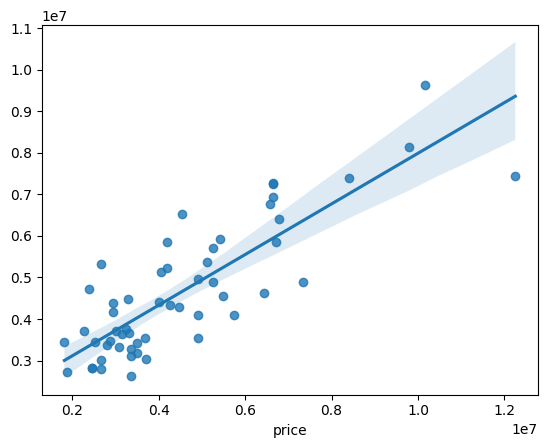

In [15]:
# actual vs Predicted
import seaborn as sns
sns.regplot(x=y_test, y=y_pred)